<a href="https://www.kaggle.com/code/samithsachidanandan/loss-functions-empirical-comparison?scriptVersionId=336640497" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



# Generate imbalanced dataset

In [2]:

X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=15,
    n_redundant=5,
    weights=[0.9, 0.1],  # 90-10 imbalance
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


# Simple model

In [3]:


class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Loss functions to compare

In [4]:

def standard_bce(y_pred, y_true):
    return nn.BCELoss()(y_pred, y_true)

def weighted_bce(y_pred, y_true):
    weights = torch.where(y_true == 1, torch.tensor(9.0), torch.tensor(1.0))
    return (weights * nn.functional.binary_cross_entropy(y_pred, y_true)).mean()

def focal_loss(y_pred, y_true, gamma=2.0):
    bce = nn.functional.binary_cross_entropy(y_pred, y_true, reduction='none')
    p_t = torch.where(y_true == 1, y_pred, 1 - y_pred)
    focal_weight = (1 - p_t) ** gamma
    return (focal_weight * bce).mean()

# Training function

In [5]:

def train_with_loss(model, X_train, y_train, X_test, y_test, loss_fn, epochs=100, name="Loss"):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # Training
        y_pred = model(X_train_t)
        loss = loss_fn(y_pred, y_train_t)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_t)
            y_pred_binary = (y_pred_test > 0.5).float()
            accuracy = (y_pred_binary == y_test_t).float().mean().item()
            
            # Also compute F1 for imbalanced data
            tp = ((y_pred_binary == 1) & (y_test_t == 1)).sum().item()
            fp = ((y_pred_binary == 1) & (y_test_t == 0)).sum().item()
            fn = ((y_pred_binary == 0) & (y_test_t == 1)).sum().item()
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        model.train()
        
        test_accuracies.append({
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
        
        if (epoch + 1) % 25 == 0:
            print(f"{name} - Epoch {epoch+1}: Loss = {loss.item():.4f}, " +
                  f"Acc = {accuracy:.4f}, F1 = {f1:.4f}")
    
    return train_losses, test_accuracies

# Train with different loss functions

In [6]:
print("=" * 70)
print("Training with STANDARD Cross-Entropy (ignores imbalance)")
print("=" * 70)
model_standard = SimpleNet()
losses_standard, acc_standard = train_with_loss(
    model_standard, X_train, y_train, X_test, y_test, 
    standard_bce, epochs=100, name="Standard CE"
)

print("\n" + "=" * 70)
print("Training with WEIGHTED Cross-Entropy (accounts for imbalance)")
print("=" * 70)
model_weighted = SimpleNet()
losses_weighted, acc_weighted = train_with_loss(
    model_weighted, X_train, y_train, X_test, y_test, 
    weighted_bce, epochs=100, name="Weighted CE"
)

print("\n" + "=" * 70)
print("Training with FOCAL Loss (aggressive imbalance handling)")
print("=" * 70)
model_focal = SimpleNet()
losses_focal, acc_focal = train_with_loss(
    model_focal, X_train, y_train, X_test, y_test, 
    lambda y_pred, y_true: focal_loss(y_pred, y_true, gamma=2.0), 
    epochs=100, name="Focal Loss"
)

Training with STANDARD Cross-Entropy (ignores imbalance)
Standard CE - Epoch 25: Loss = 0.1731, Acc = 0.9133, F1 = 0.0000
Standard CE - Epoch 50: Loss = 0.0973, Acc = 0.9633, F1 = 0.7442
Standard CE - Epoch 75: Loss = 0.0172, Acc = 0.9667, F1 = 0.8148
Standard CE - Epoch 100: Loss = 0.0051, Acc = 0.9633, F1 = 0.8000

Training with WEIGHTED Cross-Entropy (accounts for imbalance)
Weighted CE - Epoch 25: Loss = 0.2870, Acc = 0.9533, F1 = 0.6500
Weighted CE - Epoch 50: Loss = 0.0887, Acc = 0.9700, F1 = 0.8302
Weighted CE - Epoch 75: Loss = 0.0086, Acc = 0.9600, F1 = 0.7600
Weighted CE - Epoch 100: Loss = 0.0015, Acc = 0.9633, F1 = 0.7843

Training with FOCAL Loss (aggressive imbalance handling)
Focal Loss - Epoch 25: Loss = 0.0304, Acc = 0.9533, F1 = 0.7308
Focal Loss - Epoch 50: Loss = 0.0040, Acc = 0.9600, F1 = 0.7692
Focal Loss - Epoch 75: Loss = 0.0003, Acc = 0.9600, F1 = 0.7778
Focal Loss - Epoch 100: Loss = 0.0001, Acc = 0.9567, F1 = 0.7547


# Extract final metrics

In [7]:

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)
print(f"Standard CE:  Acc = {acc_standard[-1]['accuracy']:.4f}, F1 = {acc_standard[-1]['f1']:.4f}")
print(f"Weighted CE:  Acc = {acc_weighted[-1]['accuracy']:.4f}, F1 = {acc_weighted[-1]['f1']:.4f}")
print(f"Focal Loss:   Acc = {acc_focal[-1]['accuracy']:.4f}, F1 = {acc_focal[-1]['f1']:.4f}")


FINAL RESULTS
Standard CE:  Acc = 0.9633, F1 = 0.8000
Weighted CE:  Acc = 0.9633, F1 = 0.7843
Focal Loss:   Acc = 0.9567, F1 = 0.7547


# Plot

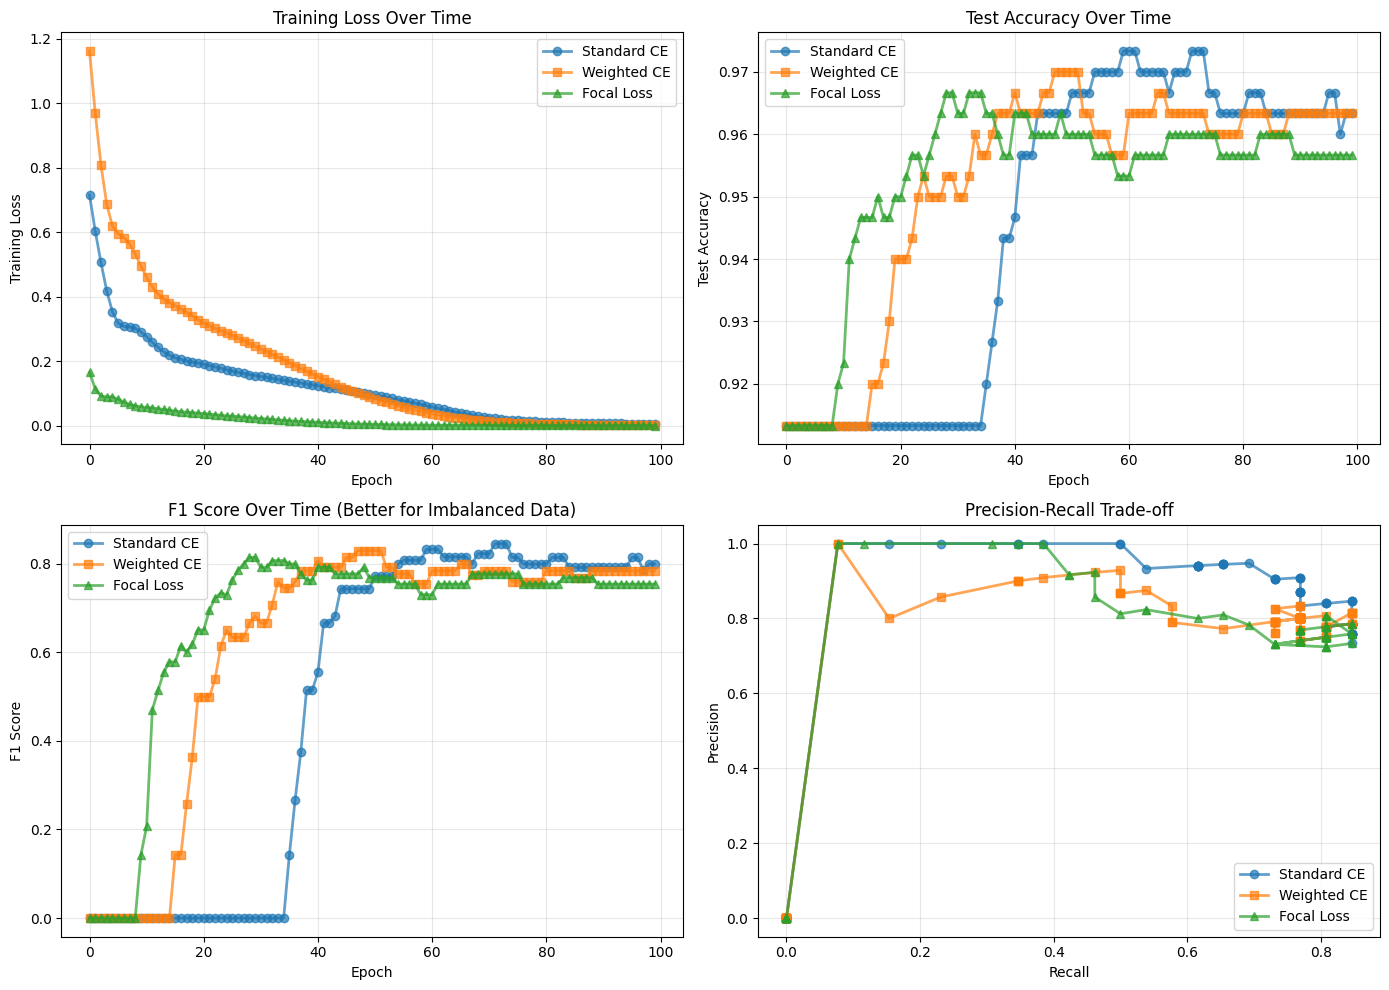

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
ax = axes[0, 0]
ax.plot(losses_standard, 'o-', label='Standard CE', alpha=0.7, linewidth=2)
ax.plot(losses_weighted, 's-', label='Weighted CE', alpha=0.7, linewidth=2)
ax.plot(losses_focal, '^-', label='Focal Loss', alpha=0.7, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Test Accuracy
ax = axes[0, 1]
ax.plot([m['accuracy'] for m in acc_standard], 'o-', label='Standard CE', alpha=0.7, linewidth=2)
ax.plot([m['accuracy'] for m in acc_weighted], 's-', label='Weighted CE', alpha=0.7, linewidth=2)
ax.plot([m['accuracy'] for m in acc_focal], '^-', label='Focal Loss', alpha=0.7, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: F1 Score
ax = axes[1, 0]
ax.plot([m['f1'] for m in acc_standard], 'o-', label='Standard CE', alpha=0.7, linewidth=2)
ax.plot([m['f1'] for m in acc_weighted], 's-', label='Weighted CE', alpha=0.7, linewidth=2)
ax.plot([m['f1'] for m in acc_focal], '^-', label='Focal Loss', alpha=0.7, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Over Time (Better for Imbalanced Data)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Precision-Recall Trade-off
ax = axes[1, 1]
precision_standard = [m['precision'] for m in acc_standard]
recall_standard = [m['recall'] for m in acc_standard]
precision_weighted = [m['precision'] for m in acc_weighted]
recall_weighted = [m['recall'] for m in acc_weighted]
precision_focal = [m['precision'] for m in acc_focal]
recall_focal = [m['recall'] for m in acc_focal]


ax.plot(recall_standard, precision_standard, 'o-', label='Standard CE', alpha=0.7, linewidth=2)
ax.plot(recall_weighted, precision_weighted, 's-', label='Weighted CE', alpha=0.7, linewidth=2)
ax.plot(recall_focal, precision_focal, '^-', label='Focal Loss', alpha=0.7, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()